In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
today_str = datetime.today().strftime("%Y%m%d")
today_str


'20260216'

In [3]:
start_date = '1950-01-01'
end_date = '2025-09-30'


In [4]:
multpl_df = pd.read_pickle("../data/multpl_datasets_snapshot_20260216.pickle")
fred_df = pd.read_pickle("../data/fred_api_datasets_snapshot_20260216.pickle")

# grok_df = pd.read_excel("../data/grok_quarter_classifications_20260201.xlsx")
# grok_df.columns = grok_df.columns.str.strip()
# grok_df = grok_df.map(lambda x: x.strip() if isinstance(x, str) else x)
# grok_df['market_code'] = grok_df['primary_class'].astype('category').cat.codes
# grok_df = grok_df.rename(columns={'quarter': 'date'})
# grok_df = grok_df.set_index('date')
# grok_df.index = grok_df.index.astype(str)
# grok_df.to_csv("../data/grok_quarter_classifications_" + today_str + ".csv")
# grok_df.to_pickle("../data/grok_quarter_classifications_" + today_str + ".pickle")
grok_df = pd.read_pickle("../data/grok_quarter_classifications_20260216.pickle")


In [5]:
# multpl_df.loc[start_date:end_date]

In [6]:
# fred_df.loc[start_date:end_date]

In [7]:
# grok_df.loc[start_date:end_date]

In [8]:
# df = pd.concat([price_series, div_series, gdp, gnp, baa, aaa, cpi, gs10, tb3ms], axis=1)
# df.columns = ["price","div","gdp","gnp","baa","aaa","cpi","gs10","tb3ms"]
# df = pd.concat([price_series, div_series, pe_series, book_series, gdp, gnp, baa, aaa, cpi, gs10, tb3ms], axis=1)
# df.columns = ["price","div","pe","book","gdp","gnp","baa","aaa","cpi","gs10","tb3ms"]
# df.index = df.index.strftime('%Y-%m-%d')

quarterly_df = pd.concat([multpl_df, fred_df, grok_df[['market_code']] ], axis=1)

quarterly_df['market_code'] = quarterly_df['market_code'].fillna(-1).astype('int')

quarterly_df = quarterly_df.loc[start_date:end_date] #.dropna()


# df["div_yield"] = df["div"] / df["price"]
# df["price_div"] = df["price"] / df["div"]
# df["price_gdp"] = df["price"] / df["gdp"]
# df["price_gnp"] = df["price"] / df["gnp"]
# df["div_minus_baa"] = df["div_yield"] - df["baa"] / 100
# df["credit_spread"] = (df["baa"] - df["aaa"]) / 100
# df["real_price"] = df["price"] / df["cpi"]
# df["real_price_gdp"] = df["real_price"] / df["gdp"]

quarterly_df["div_yield2"] = quarterly_df["dividend"] / quarterly_df["sp500"]
quarterly_df["price_div"] = quarterly_df["sp500"] / quarterly_df["dividend"]
quarterly_df["price_gdp"] = quarterly_df["sp500"] / quarterly_df["gdp"]
quarterly_df["price_gdp2"] = quarterly_df["sp500"] / quarterly_df["fred_gdp"]
quarterly_df["price_gnp2"] = quarterly_df["sp500"] / quarterly_df["fred_gnp"]
quarterly_df["div_minus_baa"] = quarterly_df["div_yield"] - quarterly_df["fred_baa"] / 100.0
quarterly_df["credit_spread"] = (quarterly_df["fred_baa"] - quarterly_df["fred_aaa"]) / 100.0
quarterly_df["real_price2"] = quarterly_df["sp500"] / quarterly_df["cpi"]
quarterly_df["real_price3"] = quarterly_df["sp500"] / quarterly_df["fred_cpi"]
quarterly_df["real_price_gdp2"] = quarterly_df["sp500_adj"] / quarterly_df["gdp"]


# # Calculate ratios (price-based, dividend preferred, anchored to GS10)
# q['div_yield'] = q['div_yield']  # already %
# q['ttm_pe'] = q['pe']
# q['earn_yield'] = 100 / q['ttm_pe']  # earnings yield %
# q['price_book'] = q['close'] / q['book']
# q['credit_spread'] = q['baa'] - q['aaa']
# q['term_spread'] = q['gs10'] - q['tb3ms']
# q['div_premium'] = q['div_yield'] - q['gs10']  # dividend premium over long rate
# q['earn_premium'] = q['earn_yield'] - q['gs10']  # earnings premium over long rate
# q['sp_gdp_proxy'] = q['close'] / q['gdp_lagged']  # simple S&P level to lagged GDP (valuation proxy)

quarterly_df.to_csv("../data/standardized_quarterly_data_" + today_str + ".csv")
quarterly_df.to_pickle("../data/standardized_quarterly_data_" + today_str + ".pickle")


In [9]:
# quarterly_df

In [10]:
# quarterly_df.columns

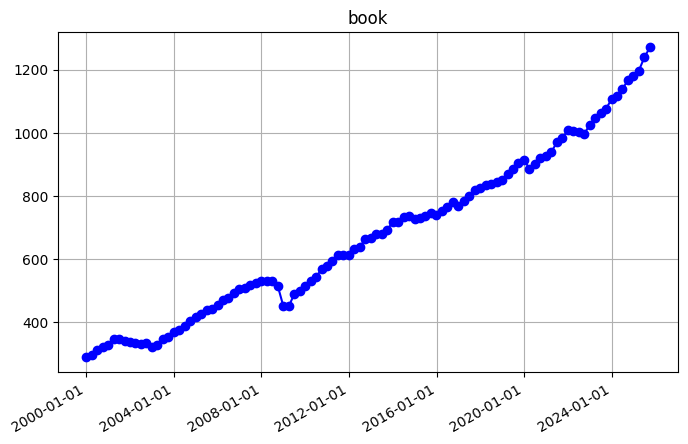

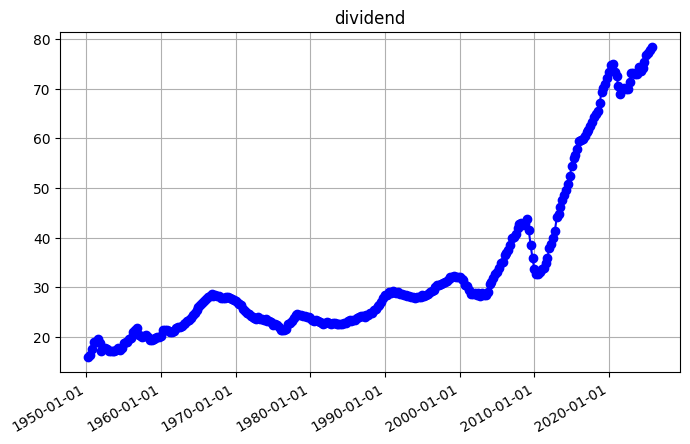

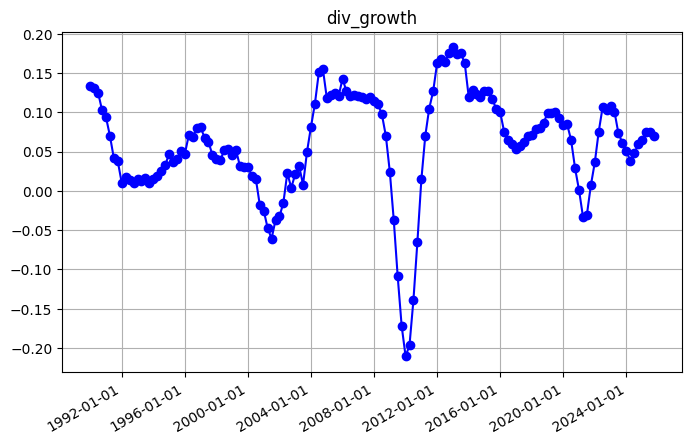

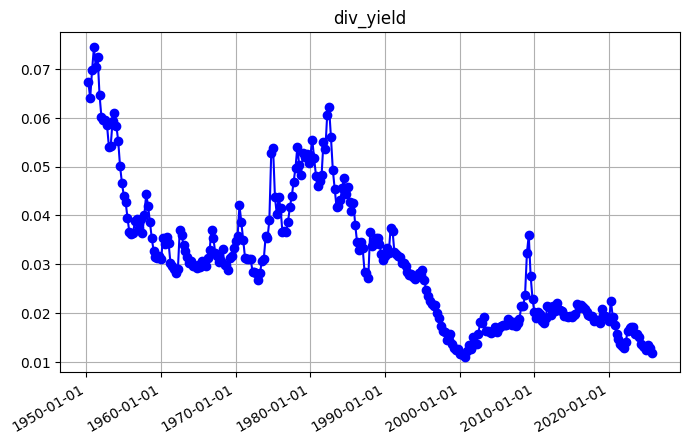

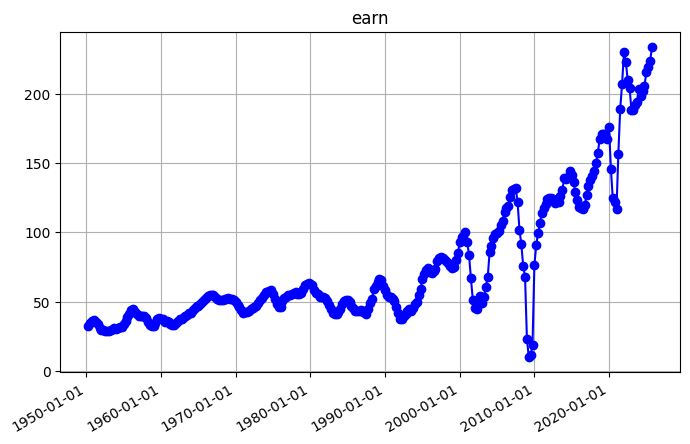

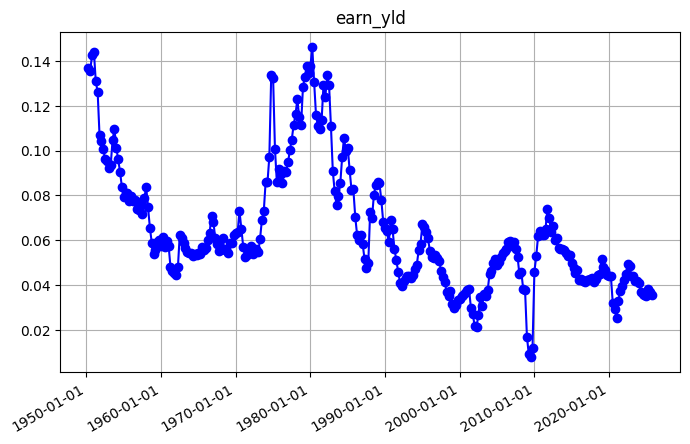

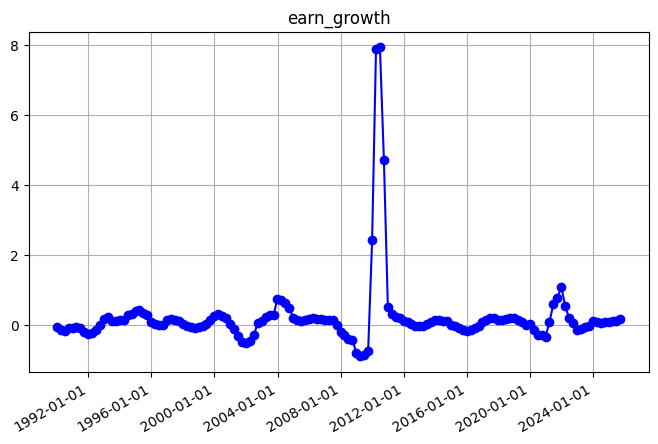

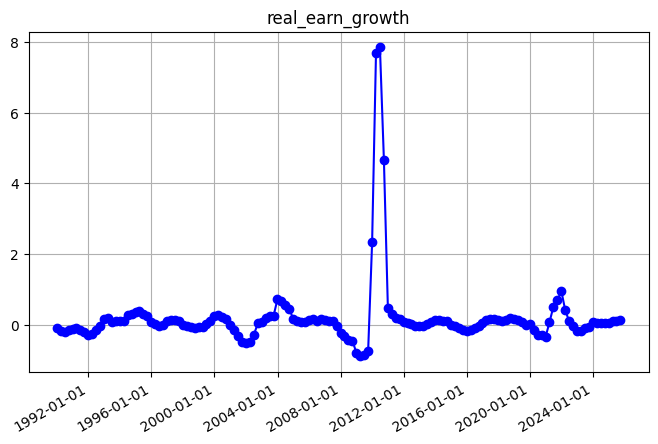

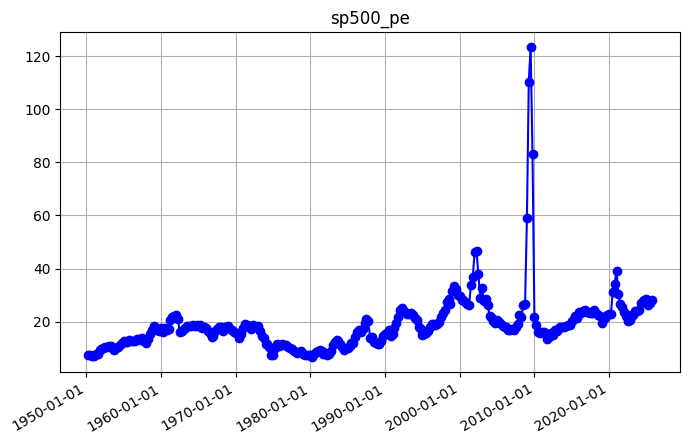

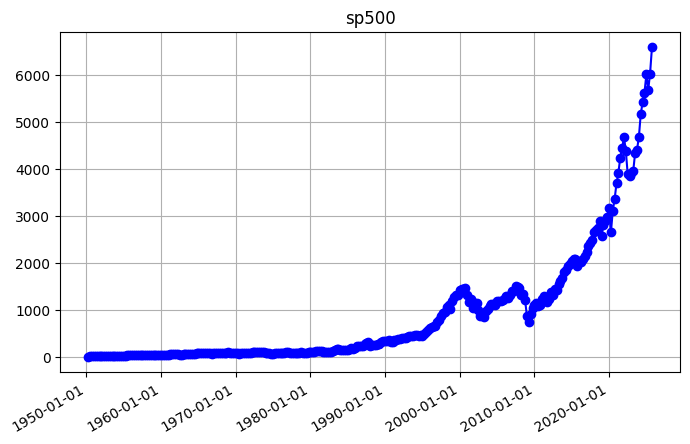

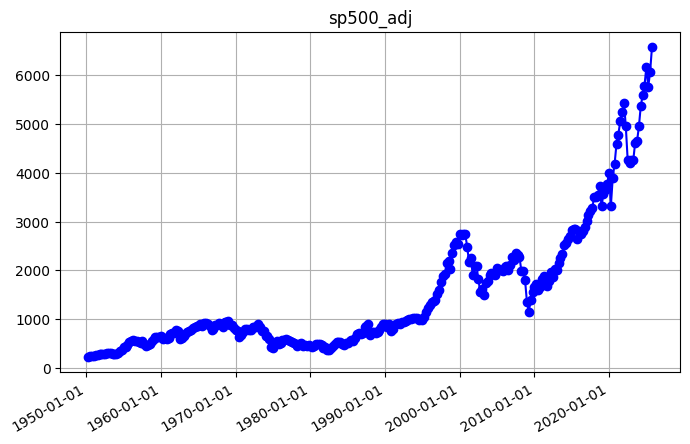

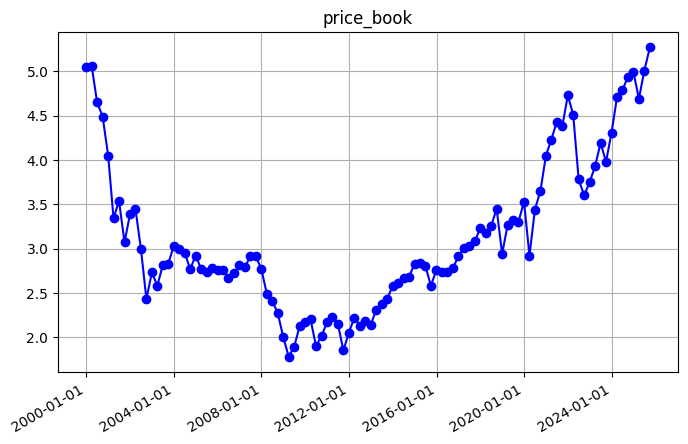

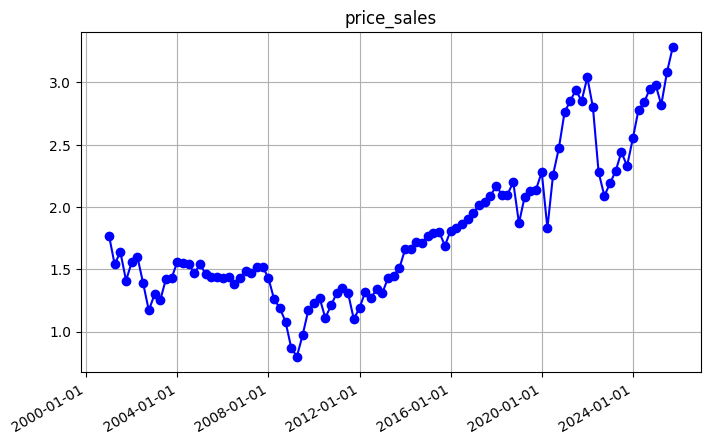

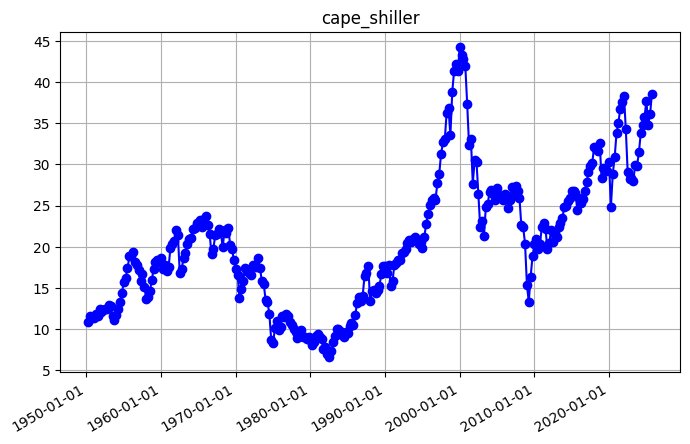

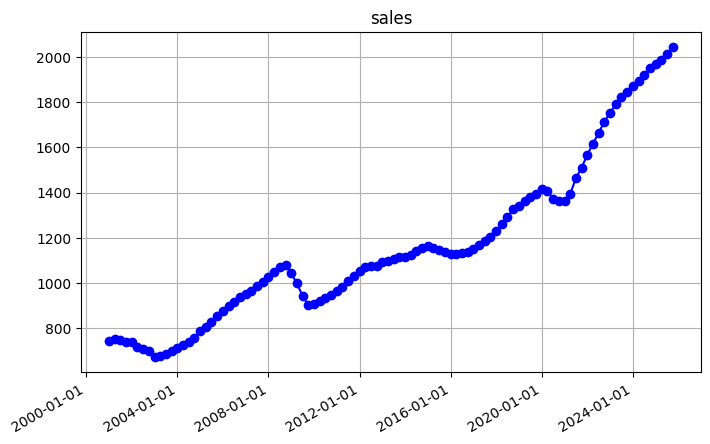

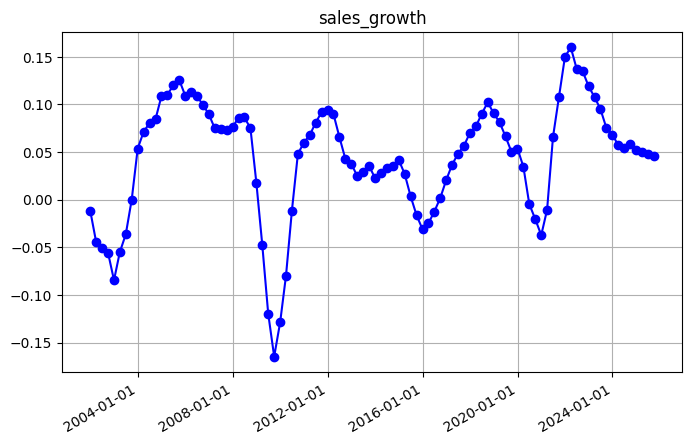

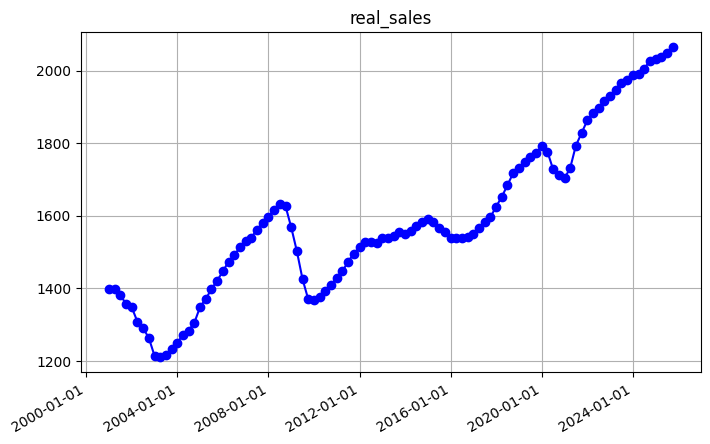

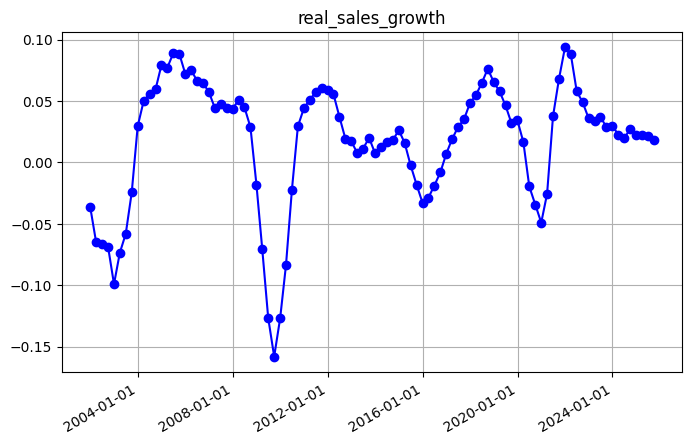

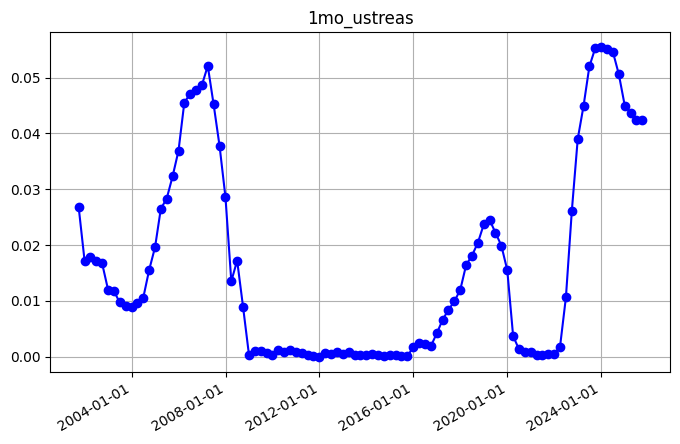

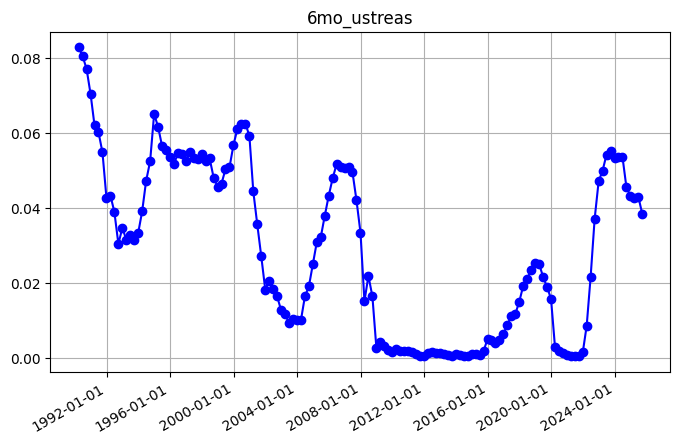

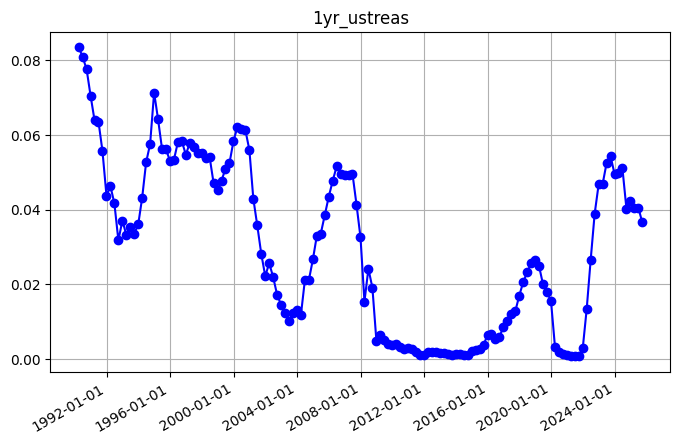

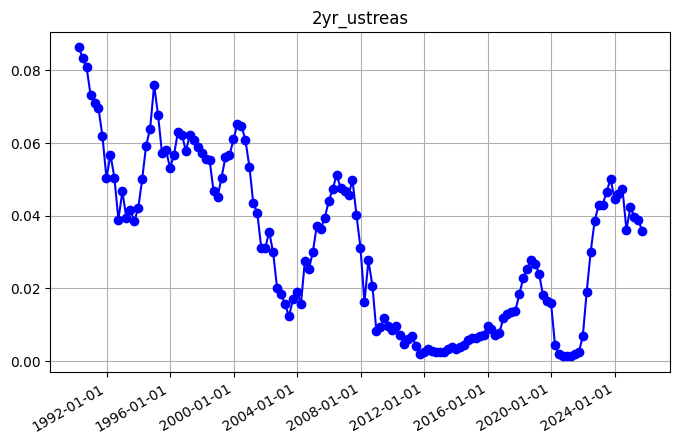

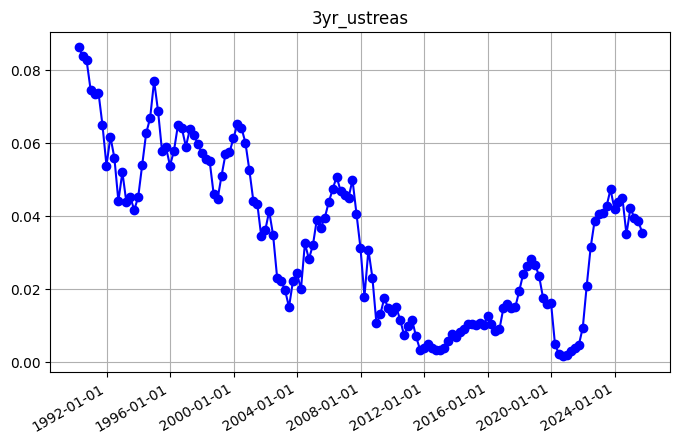

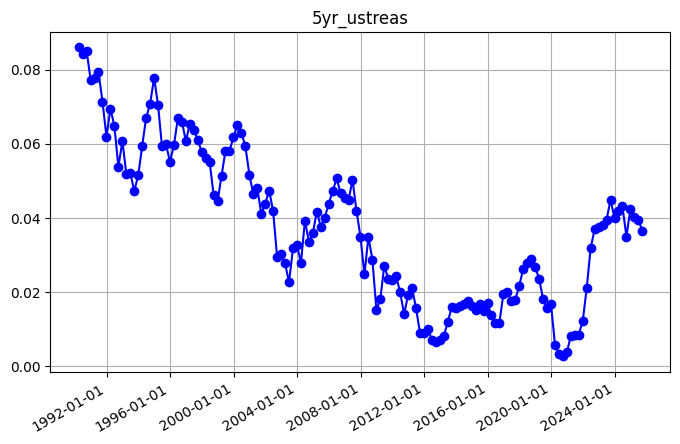

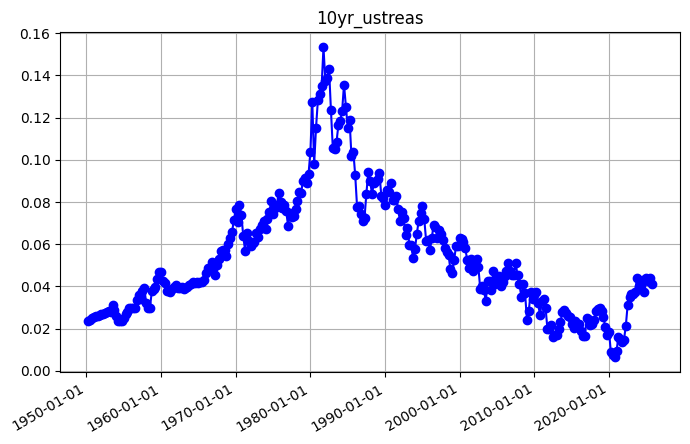

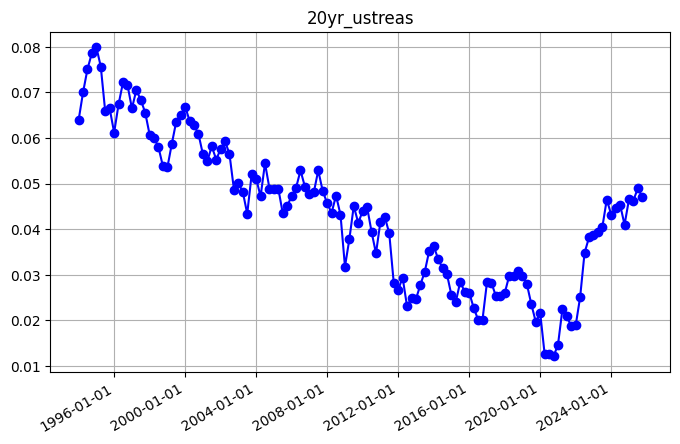

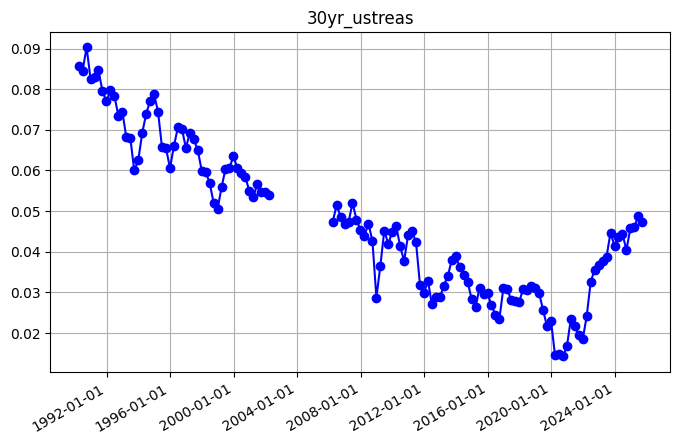

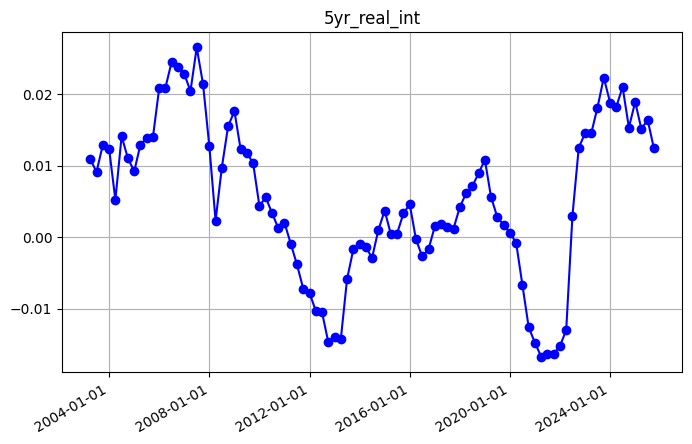

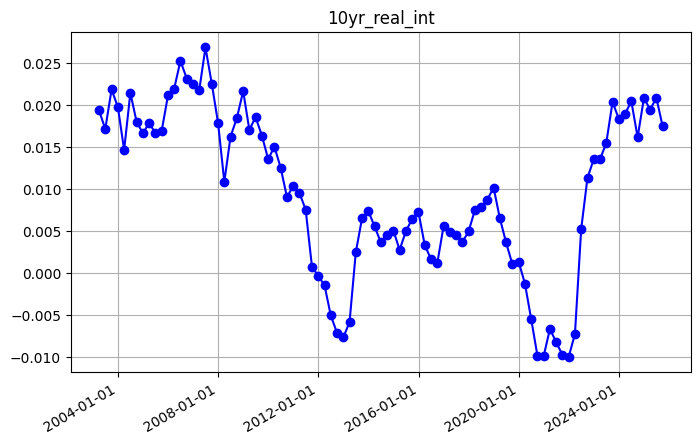

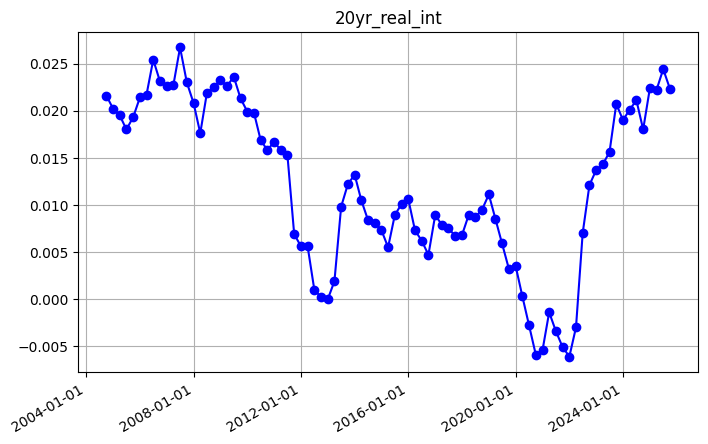

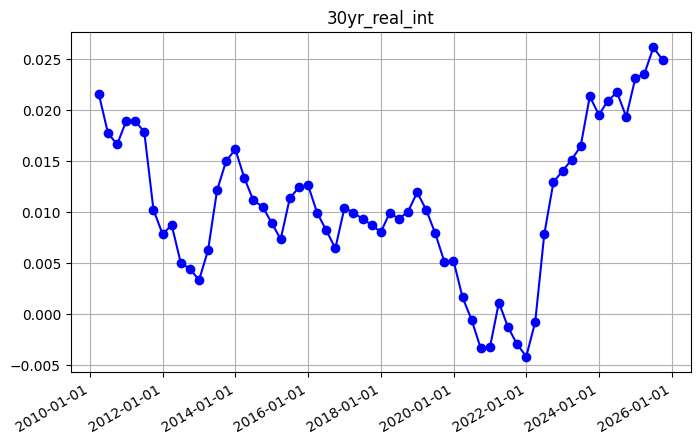

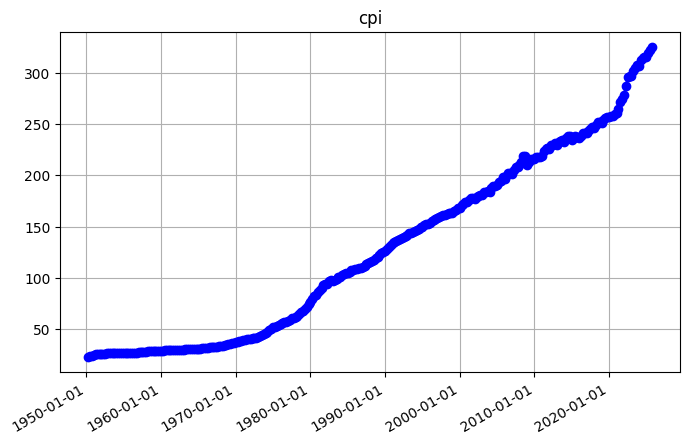

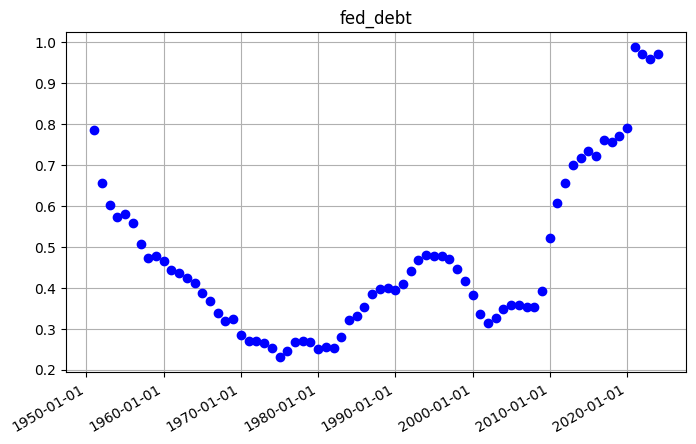

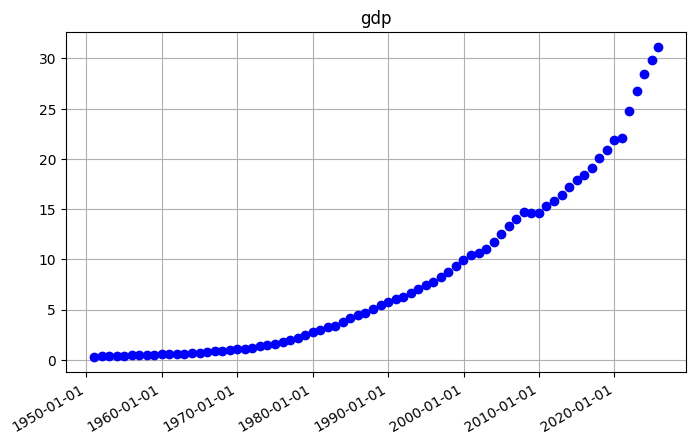

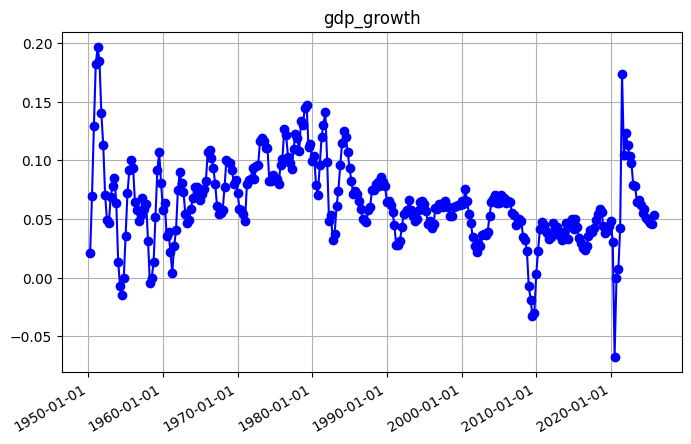

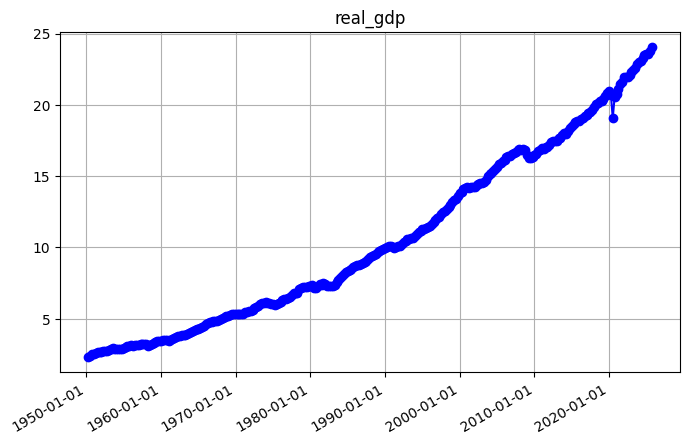

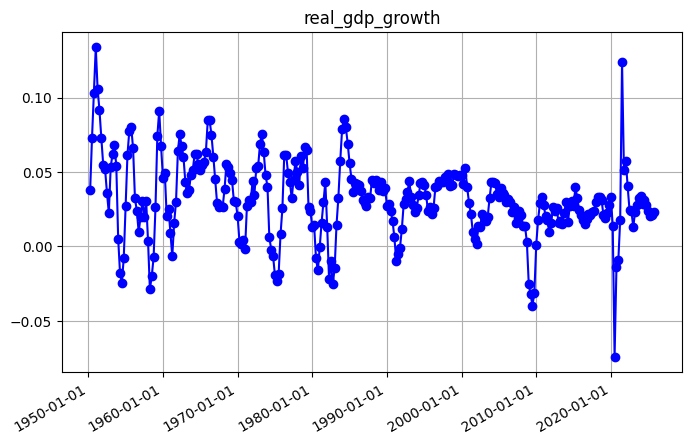

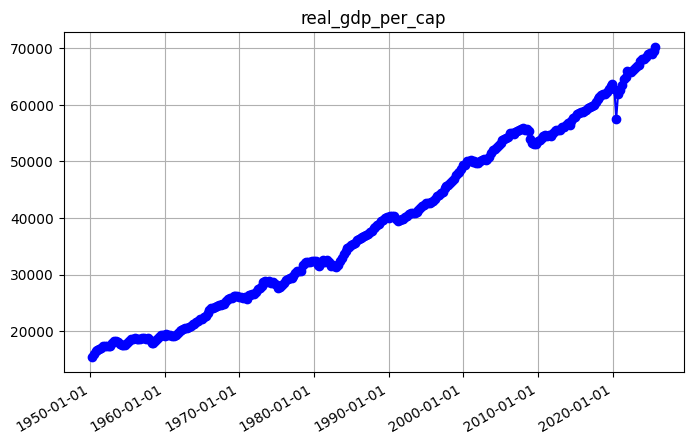

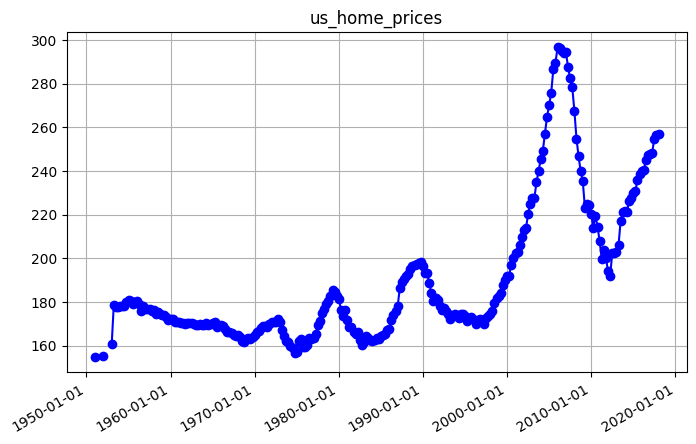

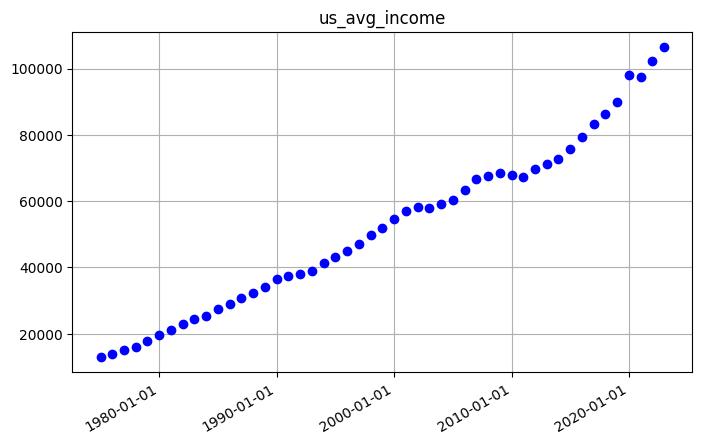

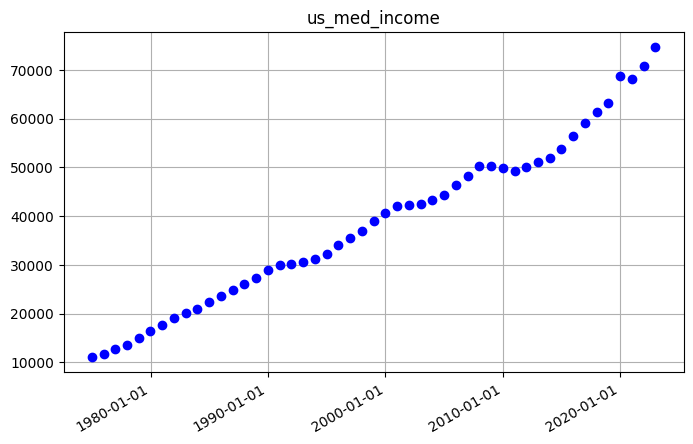

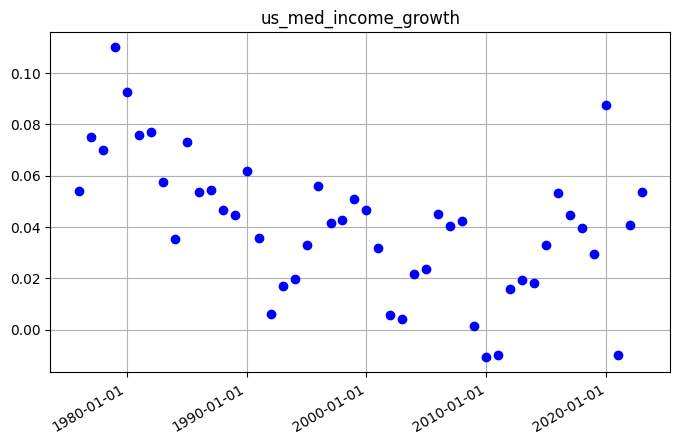

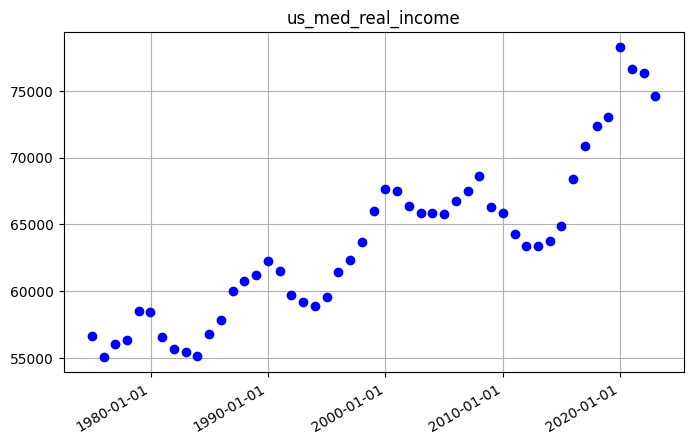

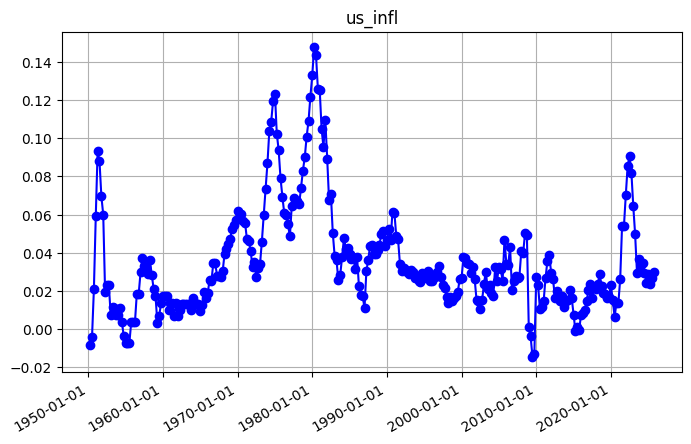

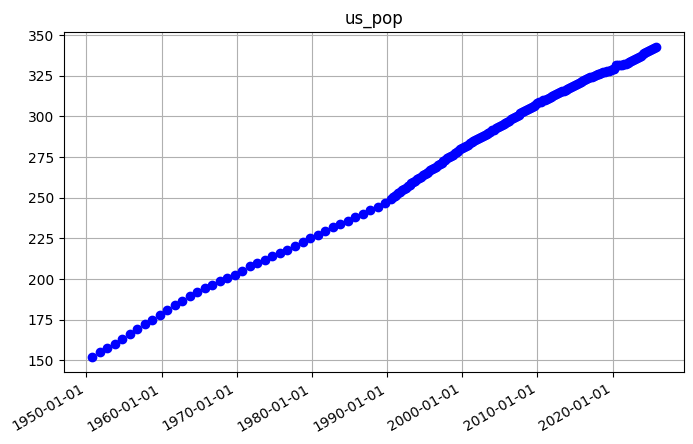

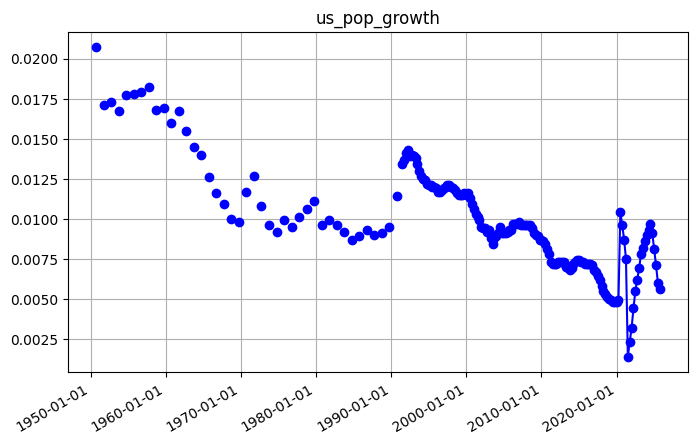

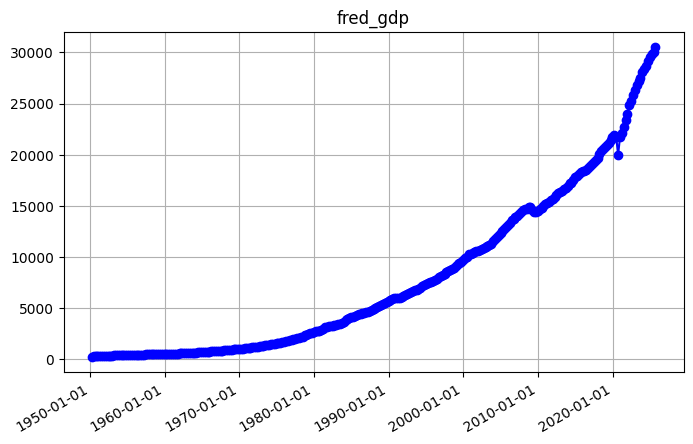

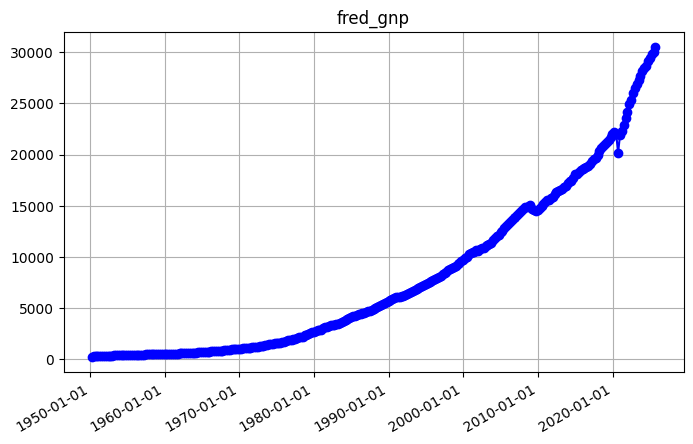

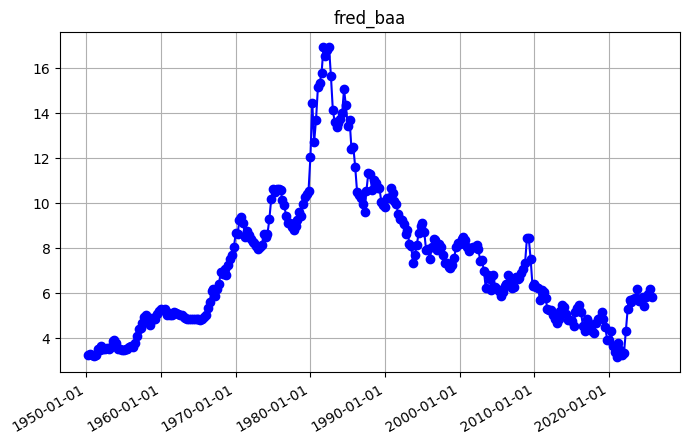

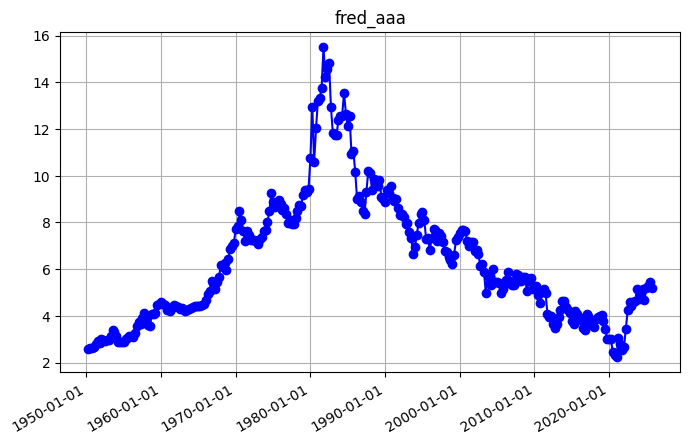

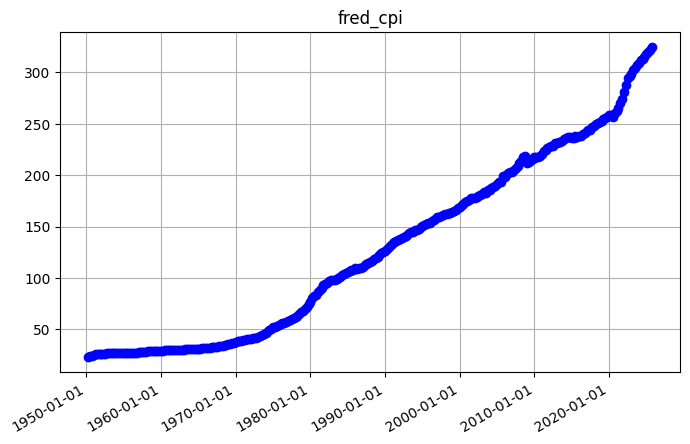

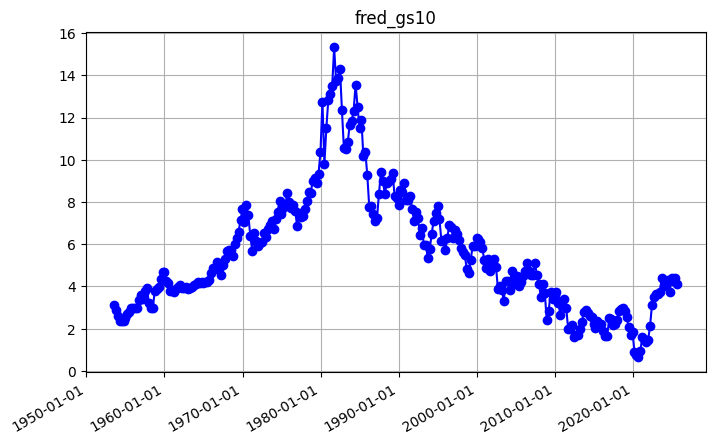

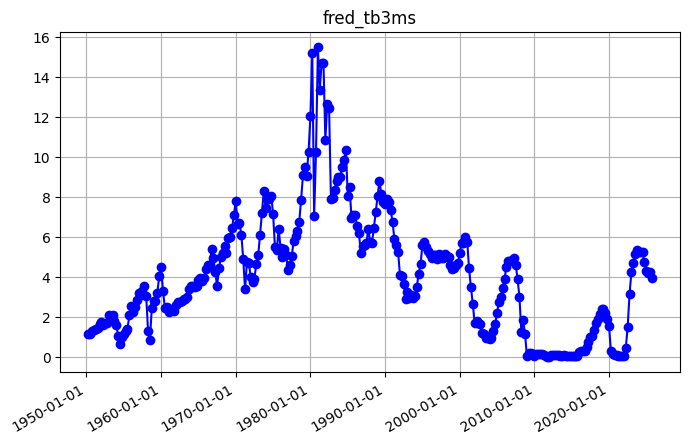

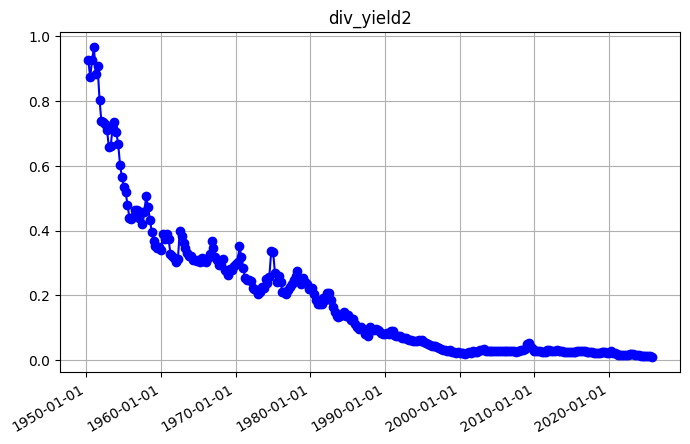

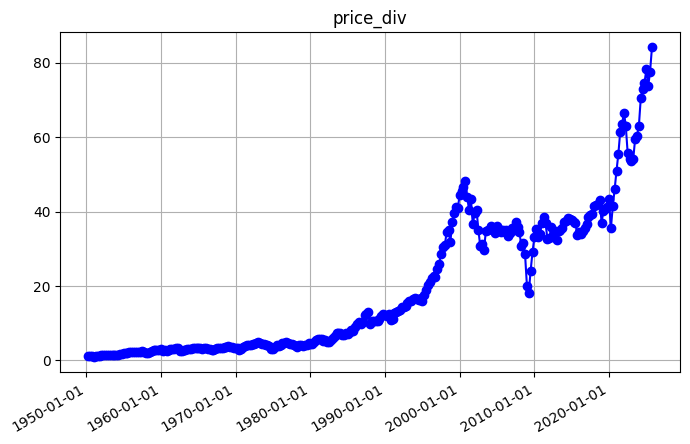

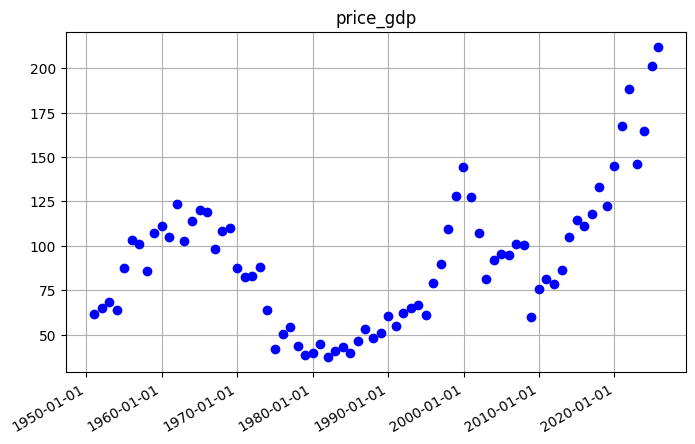

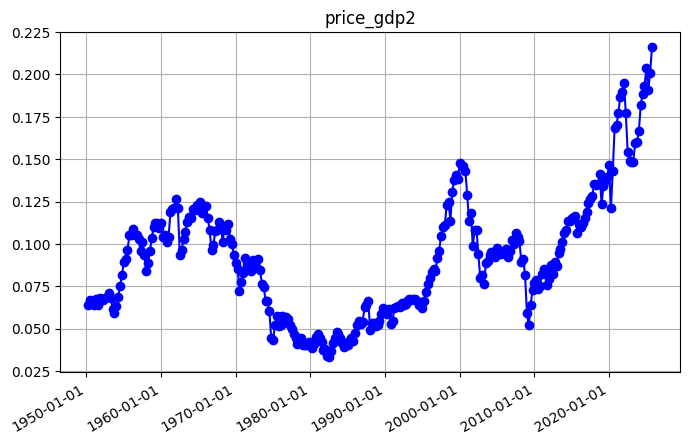

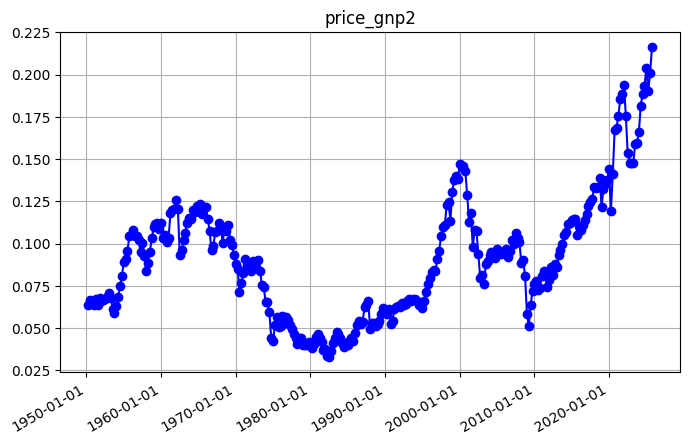

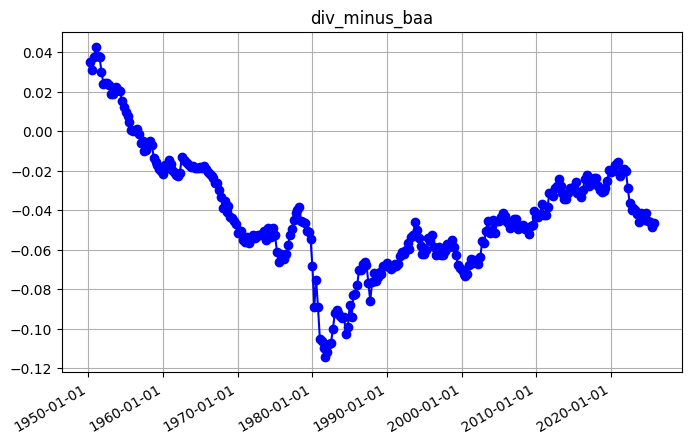

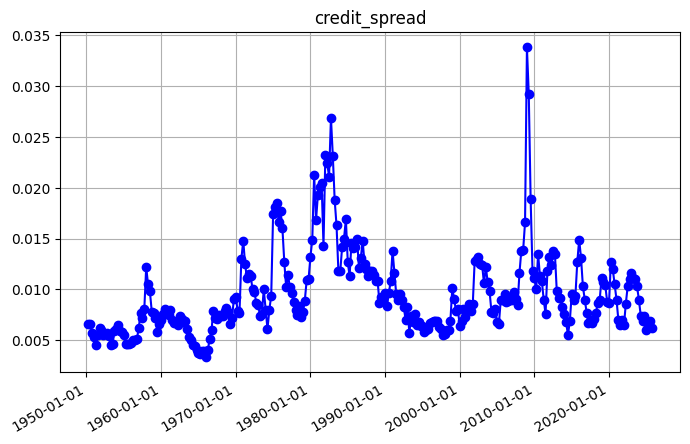

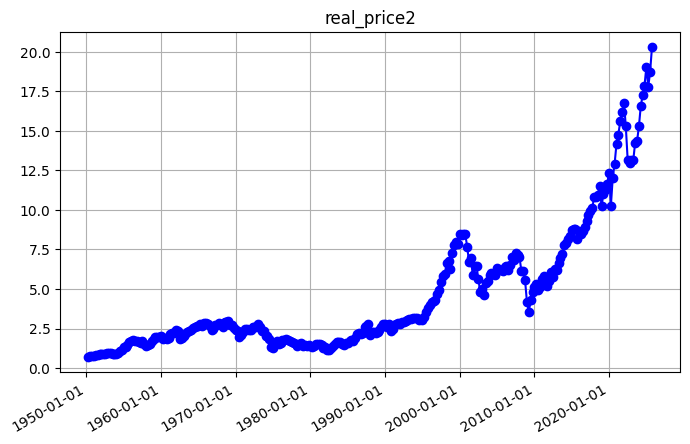

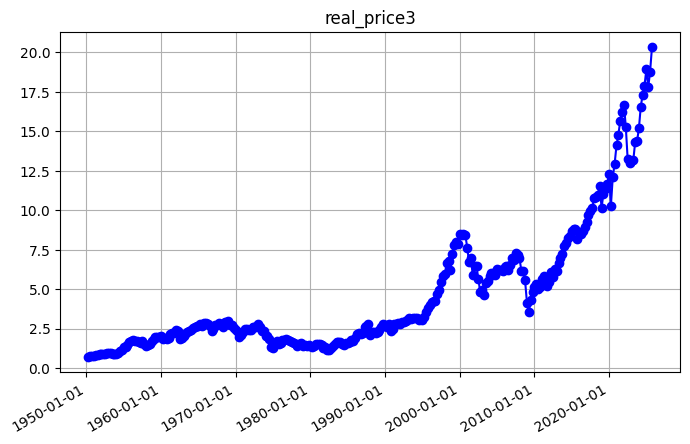

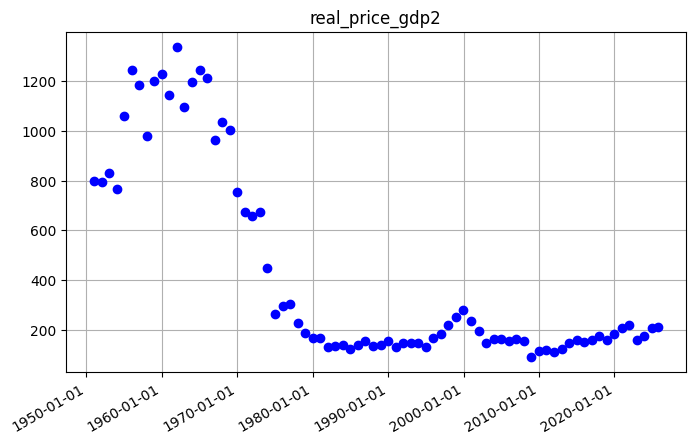

In [11]:
for col_name in quarterly_df.columns:
    if col_name == 'market_code':
        continue
    fig, ax = plt.subplots(figsize=(8, 5))
    date_strings = quarterly_df.index.values
    dates = [datetime.strptime(str(d), '%Y-%m-%d').date() for d in date_strings]
    values = quarterly_df[col_name].values
    plt.plot(dates, values, color='blue', linestyle='solid', marker='o') # Plot the data
    formatter = mdates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(formatter)
    fig.autofmt_xdate()
    plt.title(col_name)
    plt.grid(True)
    plt.show()
